<a href="https://colab.research.google.com/github/aakashkumar089/Class-notes/blob/main/OTS_SVM_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('/content/mouse_viral_study.csv')

In [3]:
df.shape

(400, 3)

In [4]:
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


In [5]:
df.columns

Index(['Med_1_mL', 'Med_2_mL', 'Virus Present'], dtype='object')

<Axes: xlabel='Med_1_mL', ylabel='Med_2_mL'>

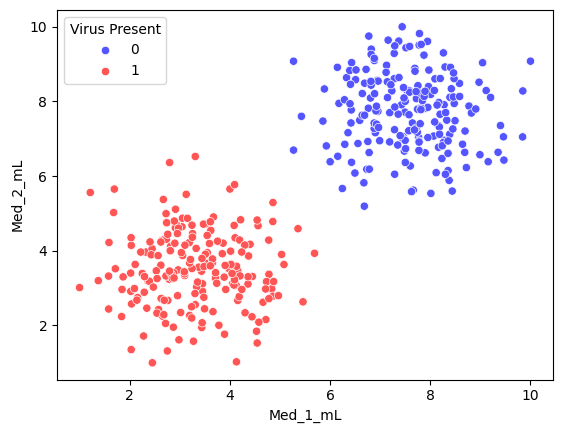

In [6]:
sns.scatterplot(x = 'Med_1_mL',y='Med_2_mL',hue='Virus Present', data=df,palette='seismic')

In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import  train_test_split

In [8]:
X = df.drop('Virus Present',axis=1)
y = df['Virus Present']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
model = SVC(kernel='linear',C=1000)

In [11]:
model.fit(X_train,y_train)

SVC(C=1000, kernel='linear')

In [12]:
def plot_svc_decesion_boundary(model,X,y):
    plt.figure(figsize=(6,5))

    sns.scatterplot(x=X.iloc[:,0],y=X.iloc[:,1], hue=y,palette='seismic')
    ax = plt.gca()

    #limit
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Grid
    xx = np.linspace(xlim[0],ylim[1],30)
    yy = np.linspace(ylim[0],ylim[1],30)
    YY,XX = np.meshgrid(yy,xx)

    xy = np.vstack([XX.ravel(),YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ## Boundary
    ax.contour(XX,YY,Z,levels=[0],colors='k')

    #Margins
    ax.contour(XX,YY,Z,levels=[-1,1],colors='red',linestyles='--')
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


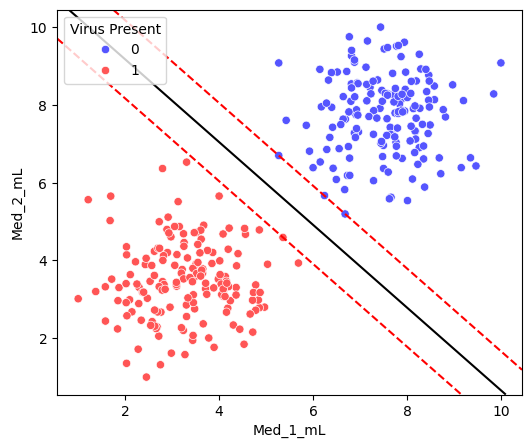

In [13]:
plot_svc_decesion_boundary(model,X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


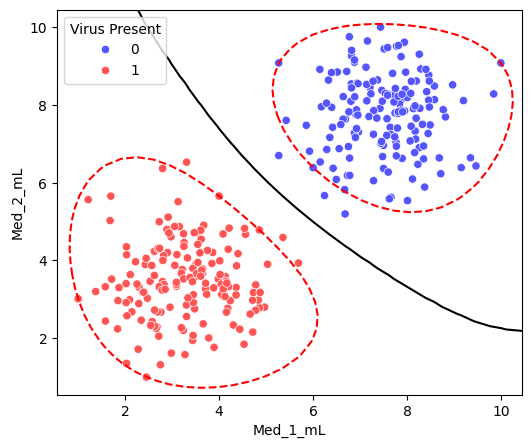

In [14]:
model = SVC(kernel='rbf',C=1,gamma='scale')
model.fit(X_train,y_train)

plot_svc_decesion_boundary(model,X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


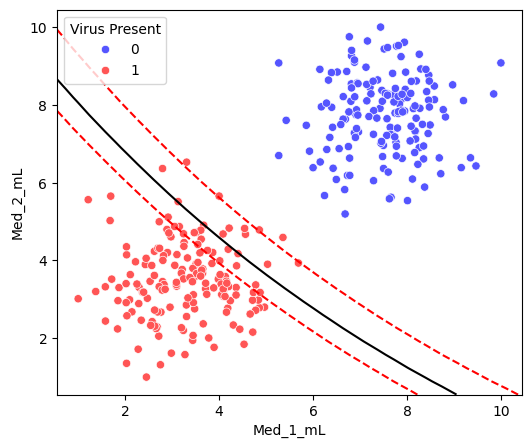

In [15]:
model = SVC(kernel='sigmoid',C=1,gamma='scale')
model.fit(X_train,y_train)

plot_svc_decesion_boundary(model,X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Linear


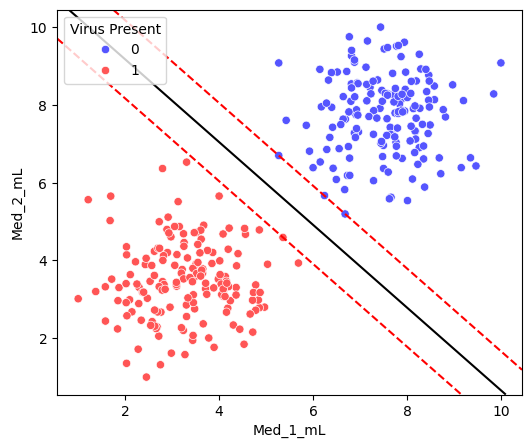

RBF


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


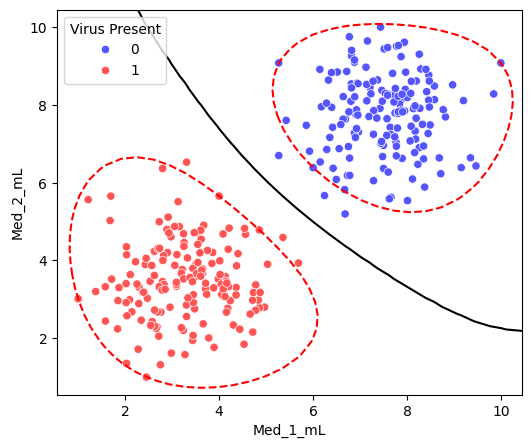

Poly


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


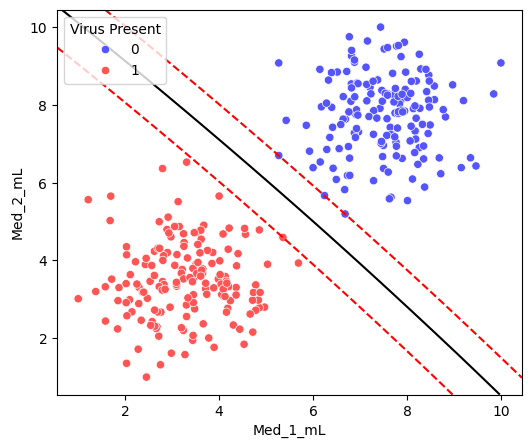

SIGMOID


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


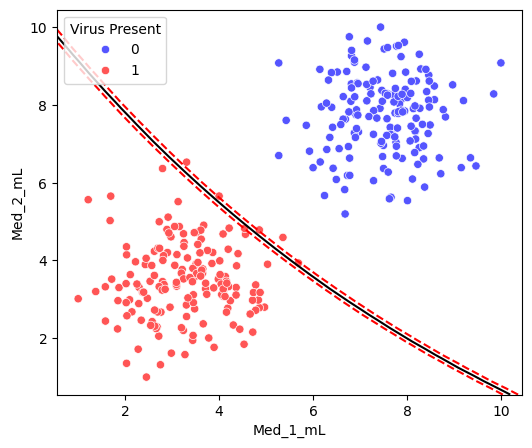

In [16]:
models = [

          ('Linear',SVC(kernel='linear',C=10)),
          ('RBF',SVC(kernel='rbf')),
          ('Poly',SVC(kernel='poly',C=10,degree=3)),
          ('SIGMOID',SVC(kernel='sigmoid',C=10)),
]

for name,model in models:
    model.fit(X_train,y_train)
    print(name)
    plot_svc_decesion_boundary(model,X_train,y_train)

In [17]:
from sklearn.metrics import accuracy_score


for name,model in models:
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy",accuracy_score(y_test,y_pred))

Linear Accuracy 1.0
RBF Accuracy 1.0
Poly Accuracy 1.0
SIGMOID Accuracy 0.025


Implement cross validation(Grid search CV)

In [18]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C':[0.1,1,5,10],
    'gamma':['scale','auto'],
    'kernel':['linear','rbf']
}


grid = GridSearchCV(SVC(),param_grid,cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


Linear


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


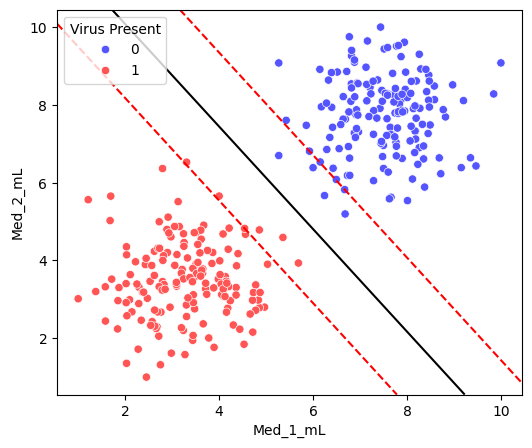

In [19]:
  models = [('Linear',SVC(kernel='linear',C=0.1))]

  for name,model in models:
    model.fit(X_train,y_train)
    print(name)
    plot_svc_decesion_boundary(model,X_train,y_train)

Gamma = 0.01


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


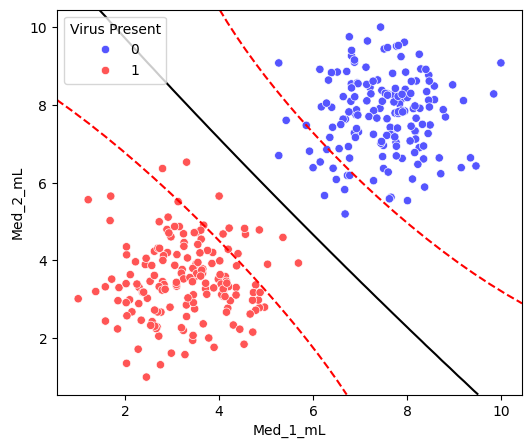

Gamma = 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


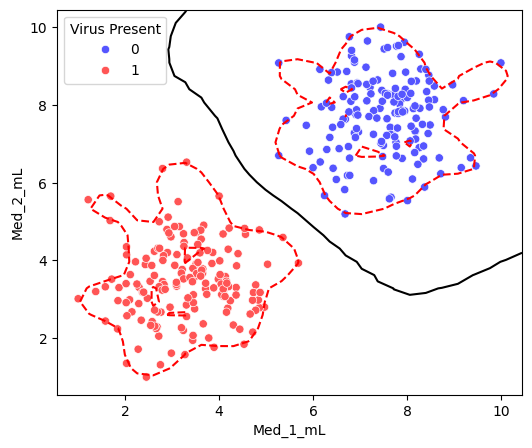

Gamma = 10


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


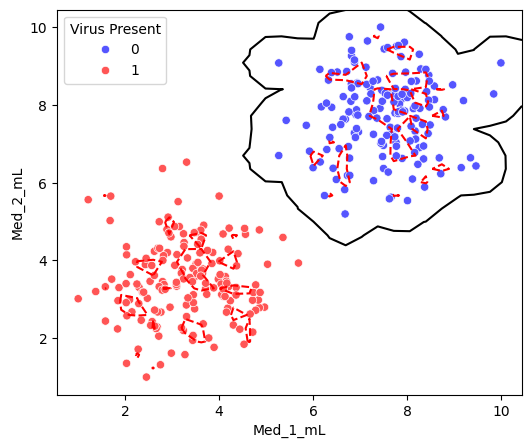

In [20]:
from sklearn.svm import SVC

gammas = [0.01,1,10]

for g in gammas:
    model = SVC(kernel='rbf',gamma=g)
    model.fit(X_train,y_train)


    print(f"Gamma = {g}")
    plot_svc_decesion_boundary(model,X_train,y_train)

In [21]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 0 0 1 0 0 1 1 0 1 1 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 1
 1 0 0 1 0 1 0 0 1 0 1 0 0 1 1 0 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1
 1 0 0 0 0 1]


In [22]:
from sklearn.metrics import accuracy_score

print('Accuracy',accuracy_score(y_test,y_pred))

Accuracy 0.9875


In [23]:
from sklearn.metrics import  confusion_matrix

In [24]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[41  1]
 [ 0 38]]


In [25]:
from sklearn.metrics import classification_report

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        42
           1       0.97      1.00      0.99        38

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



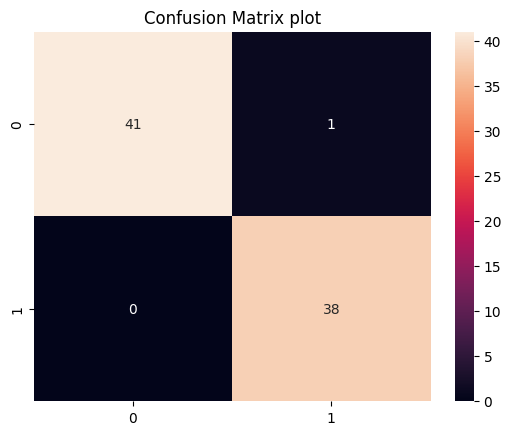

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion Matrix plot')
plt.show()

In [28]:
new_data = [[120,50]]

In [29]:
prediction = model.predict(new_data)
print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
